# 04 - Arrest Outcome Analysis

Two complementary analyses:

1. **Descriptive** — which crime types and areas have the highest arrest rates?
2. **Predictive** — train a classifier for `is_arrest` (severely imbalanced).

In [1]:
# bootstrap: make src importable
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src import config, data_loader, classification
from src.utils import apply_plot_style
apply_plot_style()

clean = data_loader.load_clean()
print('arrest rate overall:', clean['is_arrest'].mean())

02:08:05 | INFO    | src.data_loader | [start] load clean crimes_clean.parquet


02:08:05 | INFO    | src.data_loader | [done ] load clean crimes_clean.parquet in 0.41s


arrest rate overall: 0.09055633654650339


## Arrest rate by area

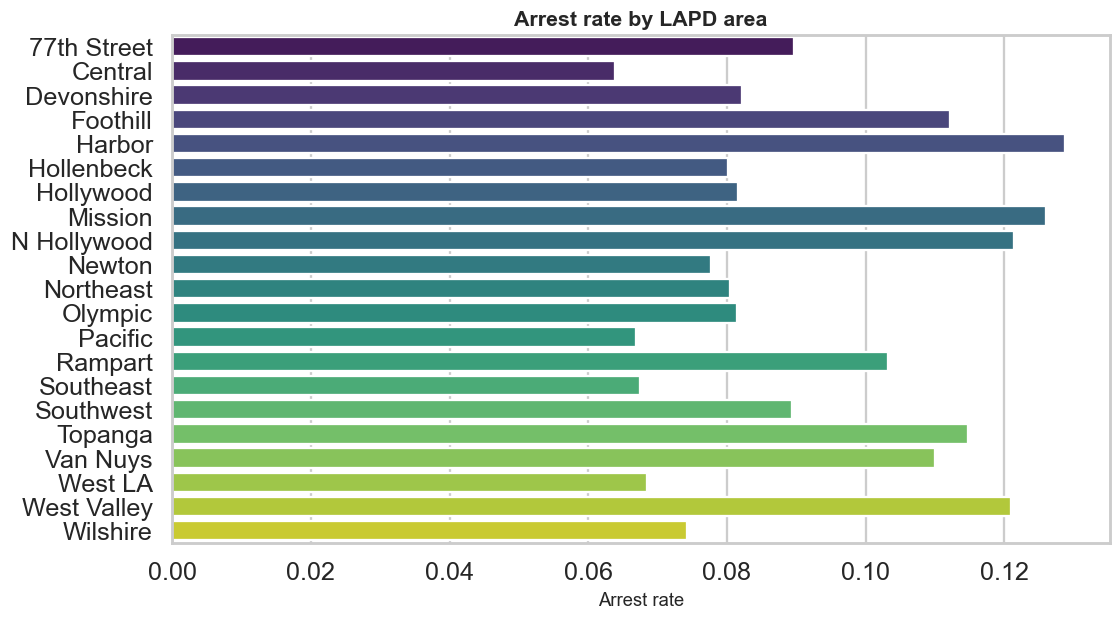

In [2]:
by_area = clean.groupby('area_name', observed=True)['is_arrest'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11,6))
sns.barplot(x=by_area.values, y=by_area.index, hue=by_area.index, palette='viridis', ax=ax, legend=False)
ax.set_title('Arrest rate by LAPD area'); ax.set_xlabel('Arrest rate'); ax.set_ylabel('');

## Arrest rate by crime type (top 15, n>1000)

In [3]:
g = (clean.groupby('crime_desc', observed=True)
         .agg(n=('dr_no','count'), arrests=('is_arrest','sum'))
         .query('n>1000'))
g['arrest_rate'] = g['arrests'] / g['n']
g.sort_values('arrest_rate', ascending=False).head(15)

,n,arrests,arrest_rate
crime_desc,,,
CRIMINAL HOMICIDE,1557,914,0.587026
ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER,1068,549,0.514045
RESISTING ARREST,1006,436,0.433400
BATTERY POLICE (SIMPLE),2533,980,0.386893
CHILD NEGLECT (SEE 300 W.I.C.),1169,442,0.378101
FAILURE TO YIELD,1597,558,0.349405
INTIMATE PARTNER - AGGRAVATED ASSAULT,12633,4261,0.337291
CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT,3551,1010,0.284427
"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",53271,12001,0.225282


## Predictive model

In [4]:
inc = pd.read_parquet(config.FEATURES_DIR / 'incident_features.parquet')
results = classification.train_classifier(inc, target='is_arrest', models=('logreg','lgbm'), sample=200_000)
for name, r in results.items():
    print(f'{name:8s}  ACC={r.accuracy:.3f}  F1={r.f1_pos:.3f}  AUC={r.roc_auc:.3f}  PR-AUC={r.pr_auc:.3f}')

02:08:06 | INFO    | src.classification | [start] train logreg -> is_arrest


C:\Users\cemil\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 32.
  warnings.warn(


02:08:07 | INFO    | src.classification | [done ] train logreg -> is_arrest in 1.60s


02:08:08 | INFO    | src.classification | [logreg] acc=0.676  f1=0.266  AUC=0.712  PR-AUC=0.184


02:08:08 | INFO    | src.classification | [start] train lgbm -> is_arrest


02:08:10 | INFO    | src.classification | [done ] train lgbm -> is_arrest in 2.57s


02:08:10 | INFO    | src.classification | [lgbm] acc=0.683  f1=0.279  AUC=0.741  PR-AUC=0.205


logreg    ACC=0.676  F1=0.266  AUC=0.712  PR-AUC=0.184
lgbm      ACC=0.683  F1=0.279  AUC=0.741  PR-AUC=0.205


**Note:** The arrest task is harder than violence classification because arrests are only ~9% of incidents, so we report **PR-AUC** as the primary metric (more informative than ROC-AUC under imbalance).